Dataset Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

C:\Users\syahp\AppData\Local\Temp\ipykernel_44376\1305602360.py:17: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(df['Class'], sort=True)


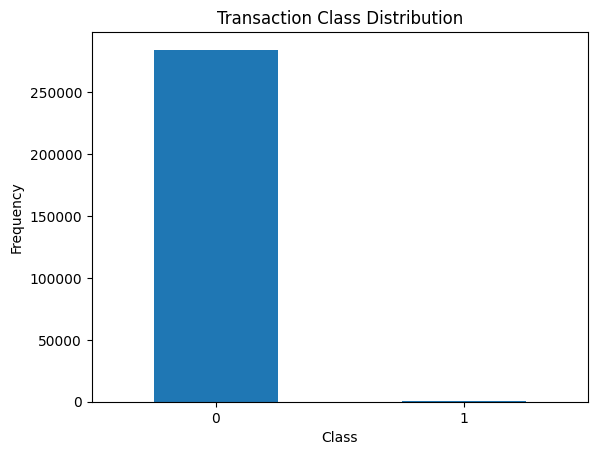


Sedang melatih model... (ini mungkin memakan waktu 1-2 menit)

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962


--- Confusion Matrix ---


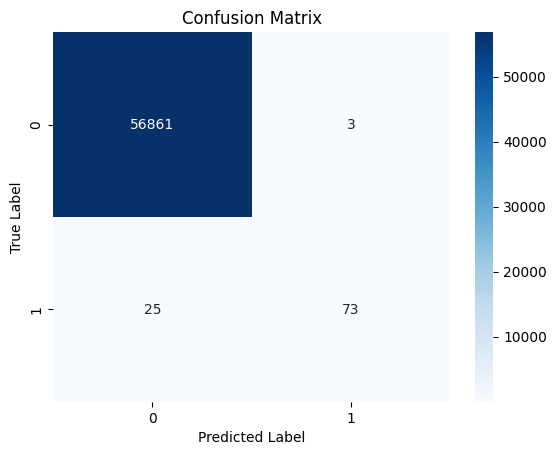


Model eksperimen berhasil disimpan di folder models/


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# 1. Load Data
# Pastikan file creditcard.csv ada di folder data/
df = pd.read_csv('../data/creditcard.csv')

print("Dataset Shape:", df.shape)
print(df.head())

# 2. Cek Imbalance Data (Penting untuk Fraud Detection)
count_classes = pd.value_counts(df['Class'], sort=True)
print("\nDistribusi Kelas (0: Normal, 1: Fraud):")
print(count_classes)

# Visualisasi sederhana
count_classes.plot(kind='bar', rot=0)
plt.title("Transaction Class Distribution")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

# 3. Persiapan Data (Splitting)
# Kita tidak melakukan scaling rumit dulu agar pipeline n8n nanti simpel
X = df.drop('Class', axis=1)
y = df['Class']

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Training Model
# Menggunakan class_weight='balanced' karena data fraud sangat sedikit
print("\nSedang melatih model... (ini mungkin memakan waktu 1-2 menit)")
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
model.fit(X_train, y_train)

# 5. Evaluasi Model
y_pred = model.predict(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 6. Simpan Model Sementara (Untuk tes save/load)
# Nanti di tahap produksi, kita akan pindahkan logika ini ke src/train.py
joblib.dump(model, '../models/fraud_model_experiment.pkl')
print("\nModel eksperimen berhasil disimpan di folder models/")